# 2D charge-density heatmaps

This notebook reads a downloaded square-lattice campaign and reconstructs physical `(x, y)` coordinates from the package's interleaved QTT site indexing. It is analysis-only and does not modify the solver environment.

Use the existing `Julia MPO density` Jupyter kernel installed for the 1D analysis notebook. It needs `CairoMakie` and `TOML`.

In [6]:
using CairoMakie
using TOML
using Statistics
using FFTW

In [2]:
# Change only the final directory name to view MPO results once available.
result_root = joinpath(
    ENV["HOME"], "MPO_HF_analysis", "results",
    "separable_aubry_andre_lside5_seed0p1_dense_hf",
)

"/Users/nicolausobrosa/MPO_HF_analysis/results/separable_aubry_andre_lside5_seed0p1_dense_hf"

In [3]:
unquote(value::AbstractString) = strip(strip(value), '"')

function read_site_density(path::AbstractString)
    lines = readlines(path)
    strip(first(lines)) == "\"site\",\"density\"" || error("unexpected density CSV header: $path")
    sites, density = Int[], Float64[]
    for line in Iterators.drop(lines, 1)
        isempty(strip(line)) && continue
        fields = split(strip(line), ','; limit=2)
        push!(sites, parse(Int, unquote(fields[1])))
        push!(density, parse(Float64, unquote(fields[2])))
    end
    sites == collect(1:length(sites)) || error("site indices are not contiguous")
    return sites, density
end

function qtt_square_coordinate(site::Integer, total_bits::Integer)
    iseven(total_bits) || error("square lattice requires an even total bit count")
    z = site - 1
    x = y = 0
    for bit in 0:(total_bits ÷ 2 - 1)
        y |= ((z >> (2bit)) & 1) << bit
        x |= ((z >> (2bit + 1)) & 1) << bit
    end
    return x, y
end

function density_grid(sites, density)
    N = length(sites)
    total_bits = round(Int, log2(N))
    2^total_bits == N && iseven(total_bits) || error("expected N=2^L with even L, got N=$N")
    side = 2^(total_bits ÷ 2)
    grid = zeros(Float64, side, side)
    for (site, value) in zip(sites, density)
        x, y = qtt_square_coordinate(site, total_bits)
        grid[x + 1, y + 1] = value
    end
    return grid
end

function load_campaign(root::AbstractString)
    isdir(root) || error("result_root is not a directory: $root")
    tasks = sort(filter(path -> isdir(path) && isfile(joinpath(path, "site_density.csv")), readdir(root; join=true)))
    isempty(tasks) && error("no completed task directories below $root")
    [begin
        sites, density = read_site_density(joinpath(task, "site_density.csv"))
        (label=replace(basename(task), r"^task_\d+_" => ""), density=density, grid=density_grid(sites, density), observables=TOML.parsefile(joinpath(task, "observables.toml")))
    end for task in tasks]
end

load_campaign (generic function with 1 method)

In [4]:
cases = load_campaign(result_root)
[(case=entry.label, N=length(entry.density), density_min=minimum(entry.density), density_max=maximum(entry.density), particle_number=entry.observables["particle_number"], energy_total=entry.observables["energy_total"]) for entry in cases]

3-element Vector{@NamedTuple{case::String, N::Int64, density_min::Float64, density_max::Float64, particle_number::Float64, energy_total::Float64}}:
 (case = "v2_0_u_1", N = 1024, density_min = 0.18370352778829344, density_max = 0.8284655576207385, particle_number = 511.9999999999996, energy_total = -467.45382029412383)
 (case = "v2_0p5_u_1", N = 1024, density_min = 0.17213610320400563, density_max = 0.8651690469251171, particle_number = 511.9999999999997, energy_total = -510.60044611766614)
 (case = "v2_2_u_0p2", N = 1024, density_min = 0.22021961739453125, density_max = 0.959434660812863, particle_number = 512.0000000000001, energy_total = -1312.0913219207634)

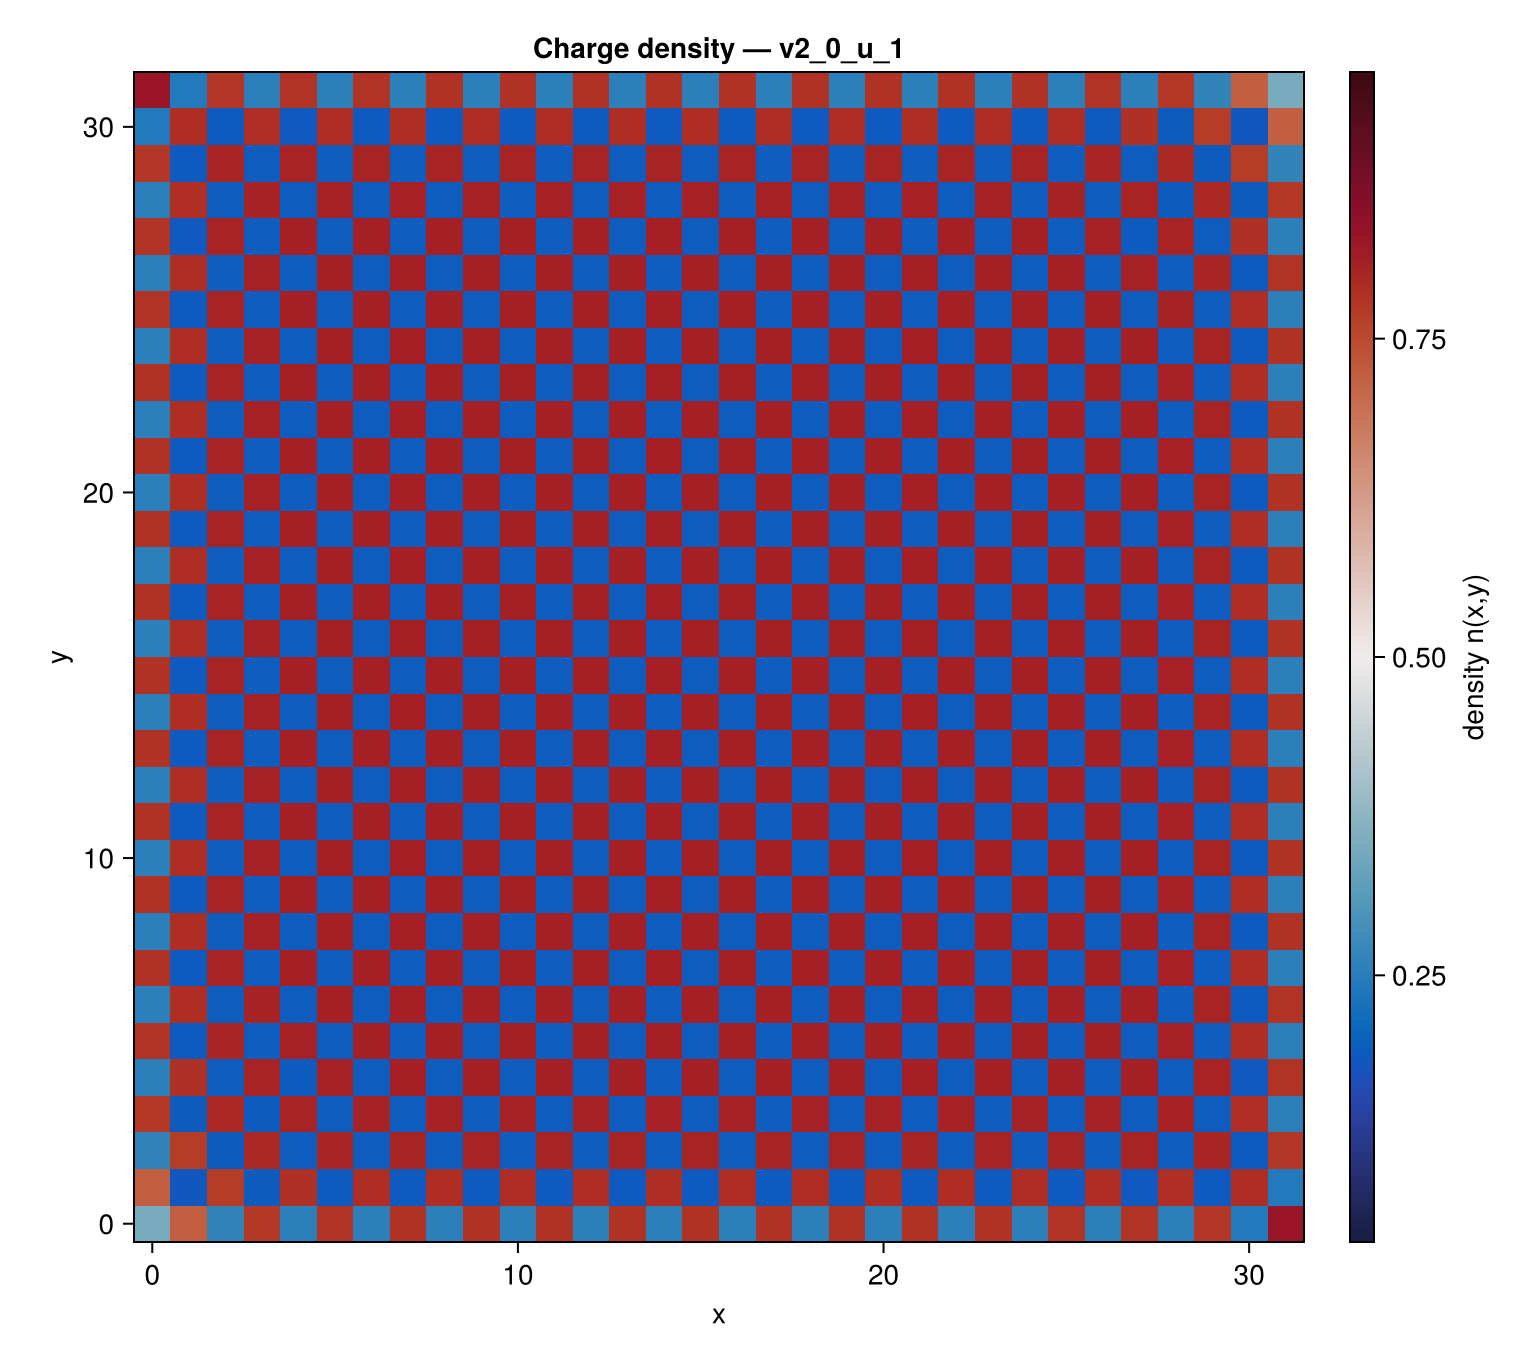

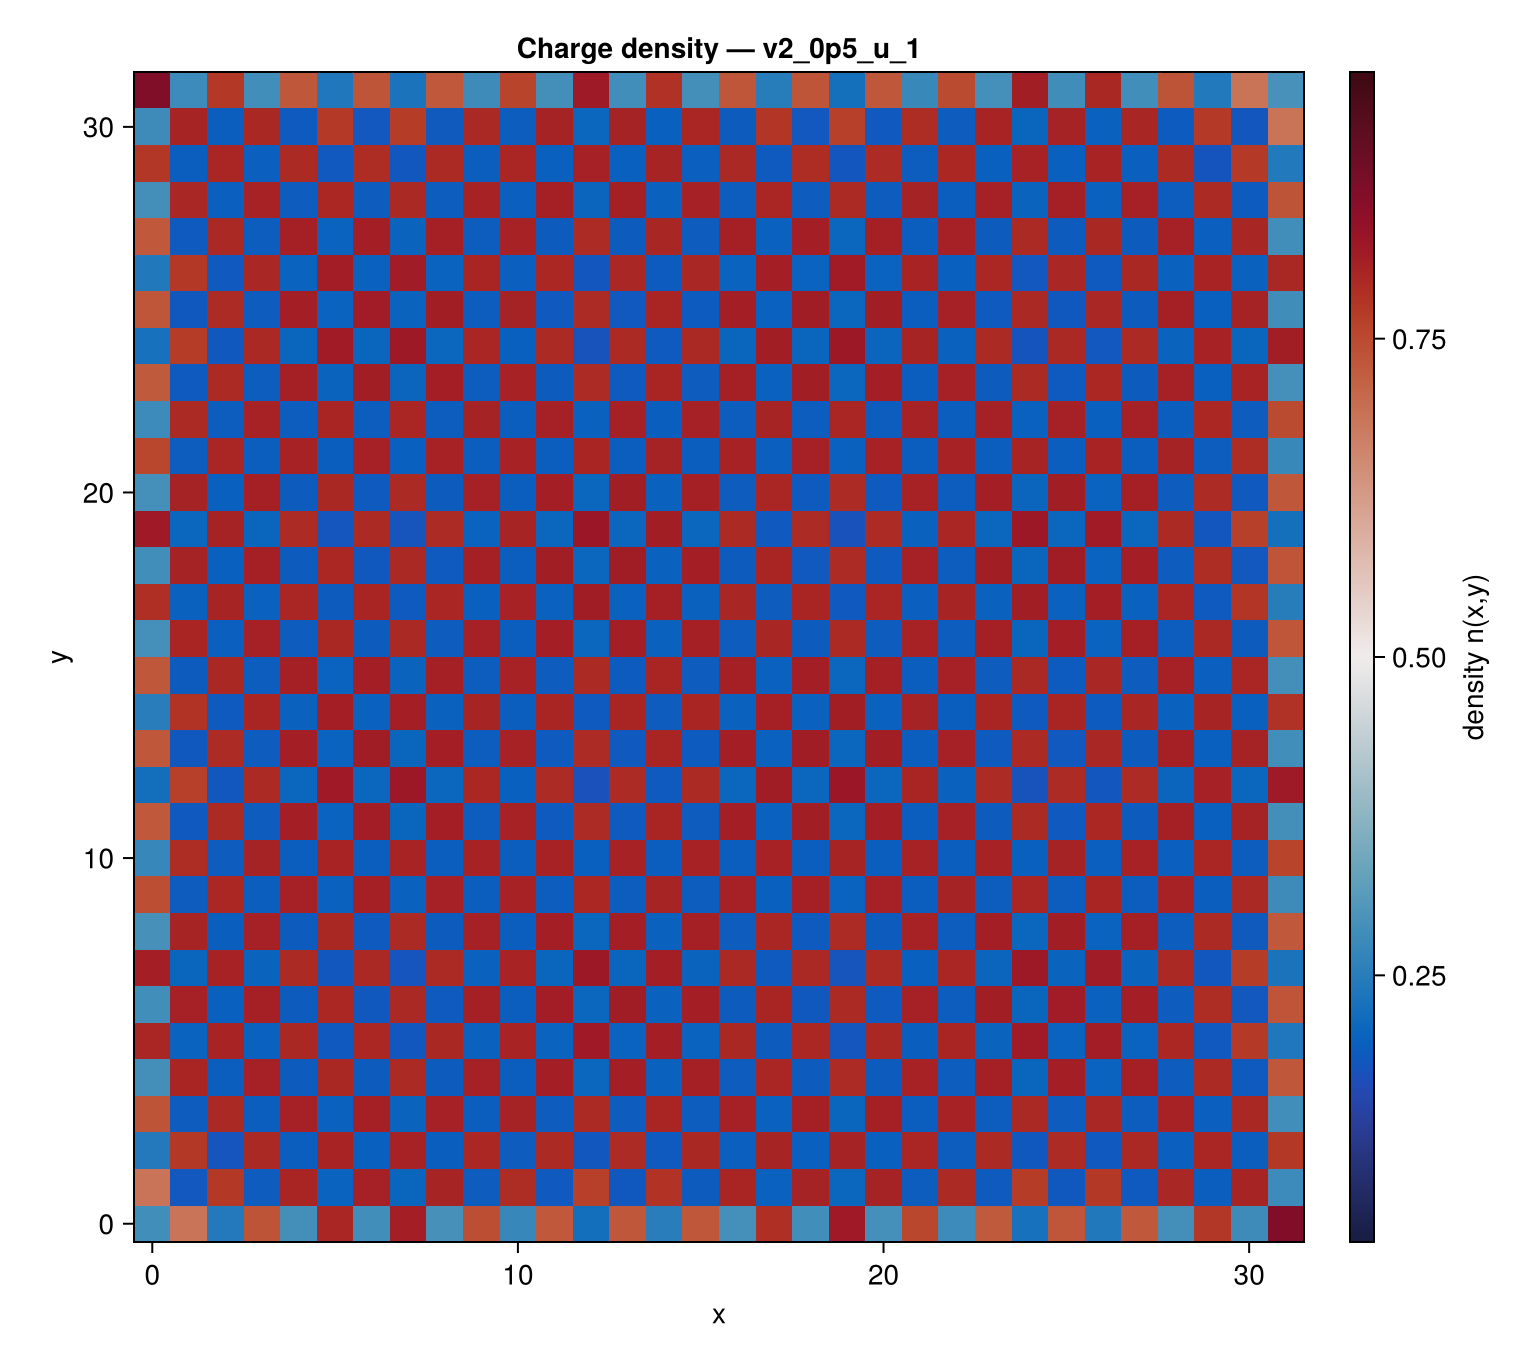

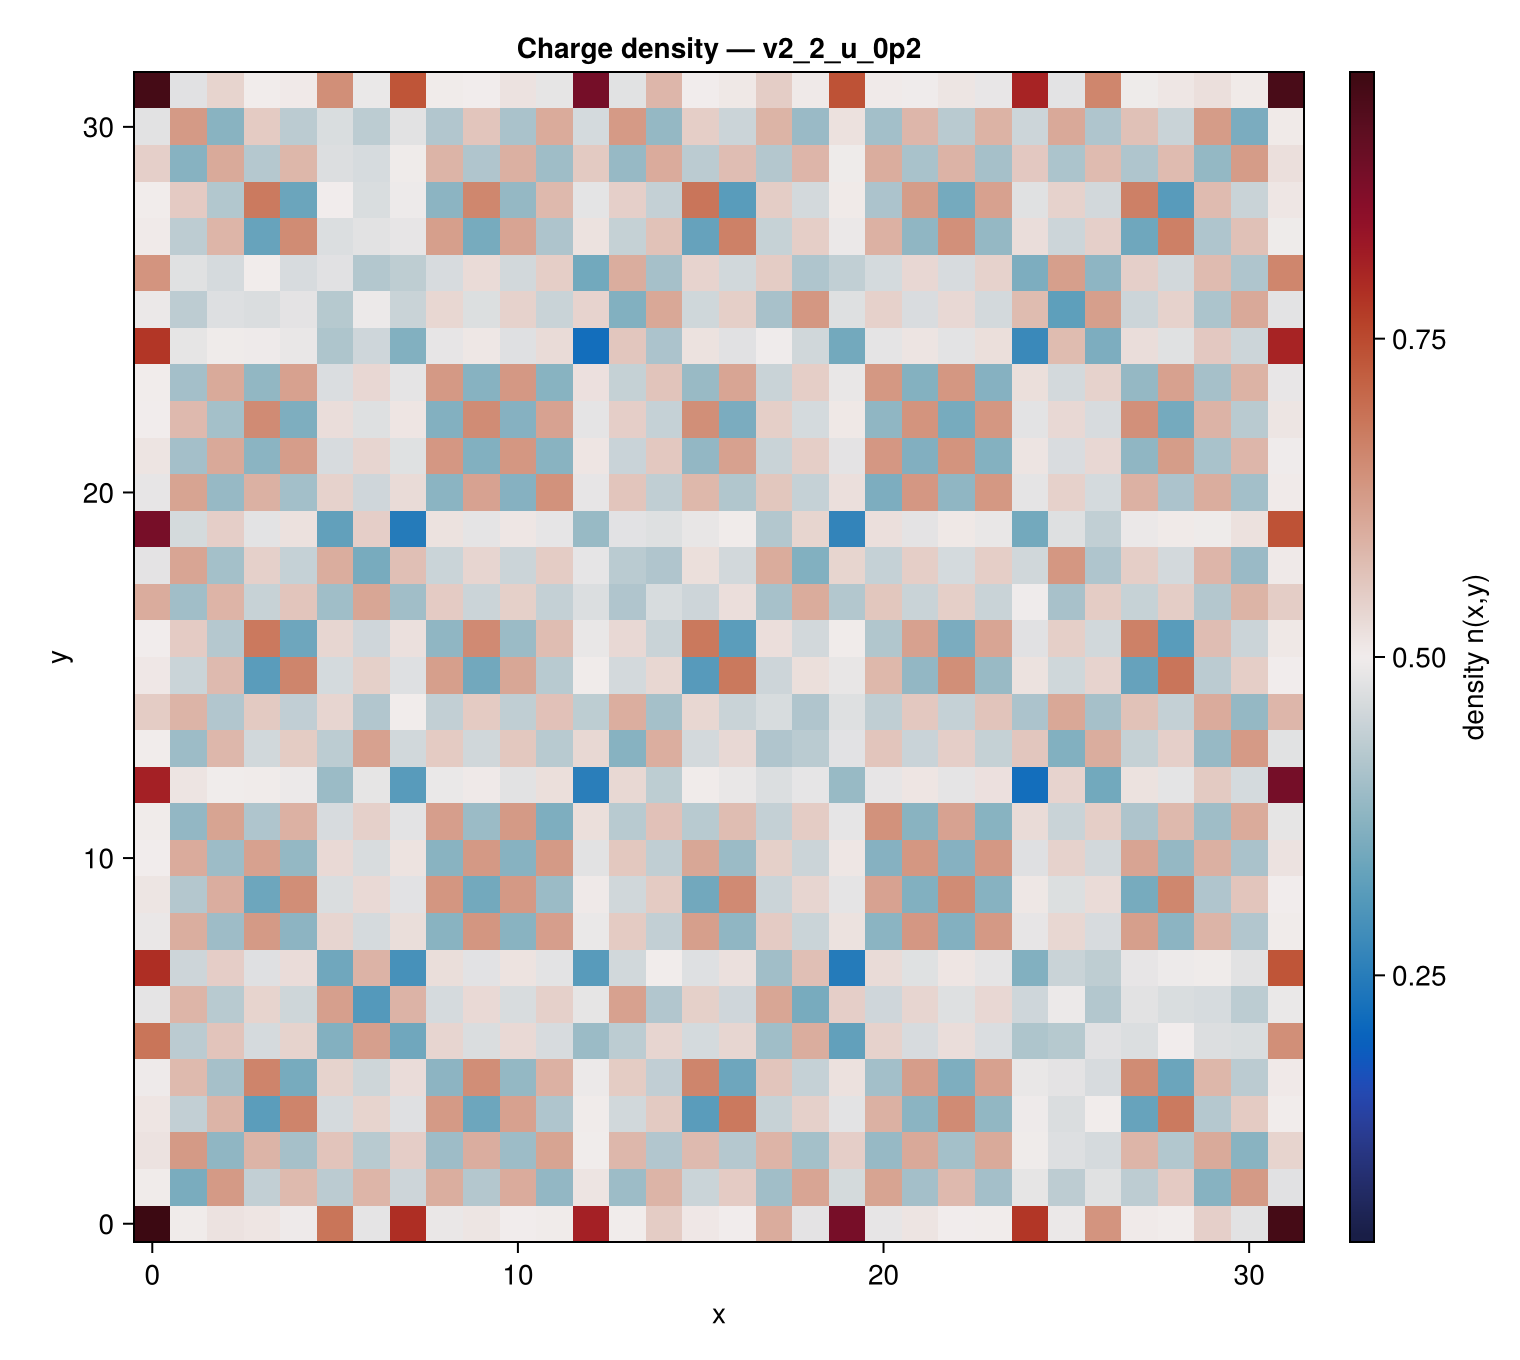

In [5]:
# A common colour scale makes density contrast comparable across cases.
all_density = reduce(vcat, (entry.density for entry in cases))
contrast = maximum(abs.(all_density .- 0.5))
colour_range = (0.5 - contrast, 0.5 + contrast)

for entry in cases
    side = size(entry.grid, 1)
    fig = Figure(size=(760, 680))
    axis = Axis(fig[1, 1], xlabel="x", ylabel="y", aspect=DataAspect(),
        title="Charge density — $(entry.label)")
    map = heatmap!(axis, 0:(side - 1), 0:(side - 1), entry.grid;
        colormap=:balance, colorrange=colour_range)
    Colorbar(fig[1, 2], map, label="density n(x,y)")
    display(fig)
end

## Two-dimensional Fourier spectrum

The plotted quantity is `log10(|FFT[n(x,y)-mean(n)]|^2/N^2)`. Removing the spatial mean removes the trivial zero-momentum filling peak. These are open-boundary finite-size spectra, so peaks are broadened rather than exact crystal momenta.

In [ ]:
function density_structure_factor(grid)
    side = size(grid, 1)
    fluctuation = grid .- mean(grid)
    power = abs2.(fft(fluctuation)) / side^2
    q = 2π .* (0:(side - 1)) ./ side
    return q, power
end

for entry in cases
    q, power = density_structure_factor(entry.grid)
    fig = Figure(size=(820, 700))
    axis = Axis(fig[1, 1], xlabel="qₓ", ylabel="qᵧ", aspect=DataAspect(),
        title="Density Fourier power — $(entry.label)")
    map = heatmap!(axis, q, q, log10.(power .+ eps(Float64)); colormap=:inferno)
    τ = sqrt(2.0) - 5.0 / 6.0
    q_module = unique(sort(mod2pi.(π .+ 2π * τ .* (-5:5))))
    qx_crosses = repeat(q_module; inner=length(q_module))
    qy_crosses = repeat(q_module; outer=length(q_module))
    scatter!(axis, qx_crosses, qy_crosses; marker=:x, markersize=9, strokewidth=2, color=:cyan)
    Colorbar(fig[1, 2], map, label="log₁₀ |FFT[n-mean(n)]|² / N")
    display(fig)
end

For the MPO campaign, change the final component of `result_root` to `separable_aubry_andre_lside5_seed0p1`. The two result trees have matching task labels and can then be compared pointwise.

## Residual-density diagnostics

A raw density FFT can be dominated by the checkerboard CDW peak. The following plots remove the uniform filling and the least-squares checkerboard component before transforming.

v2_0_u_1: mean density = 0.5, fitted CDW amplitude = -0.30344305705382113


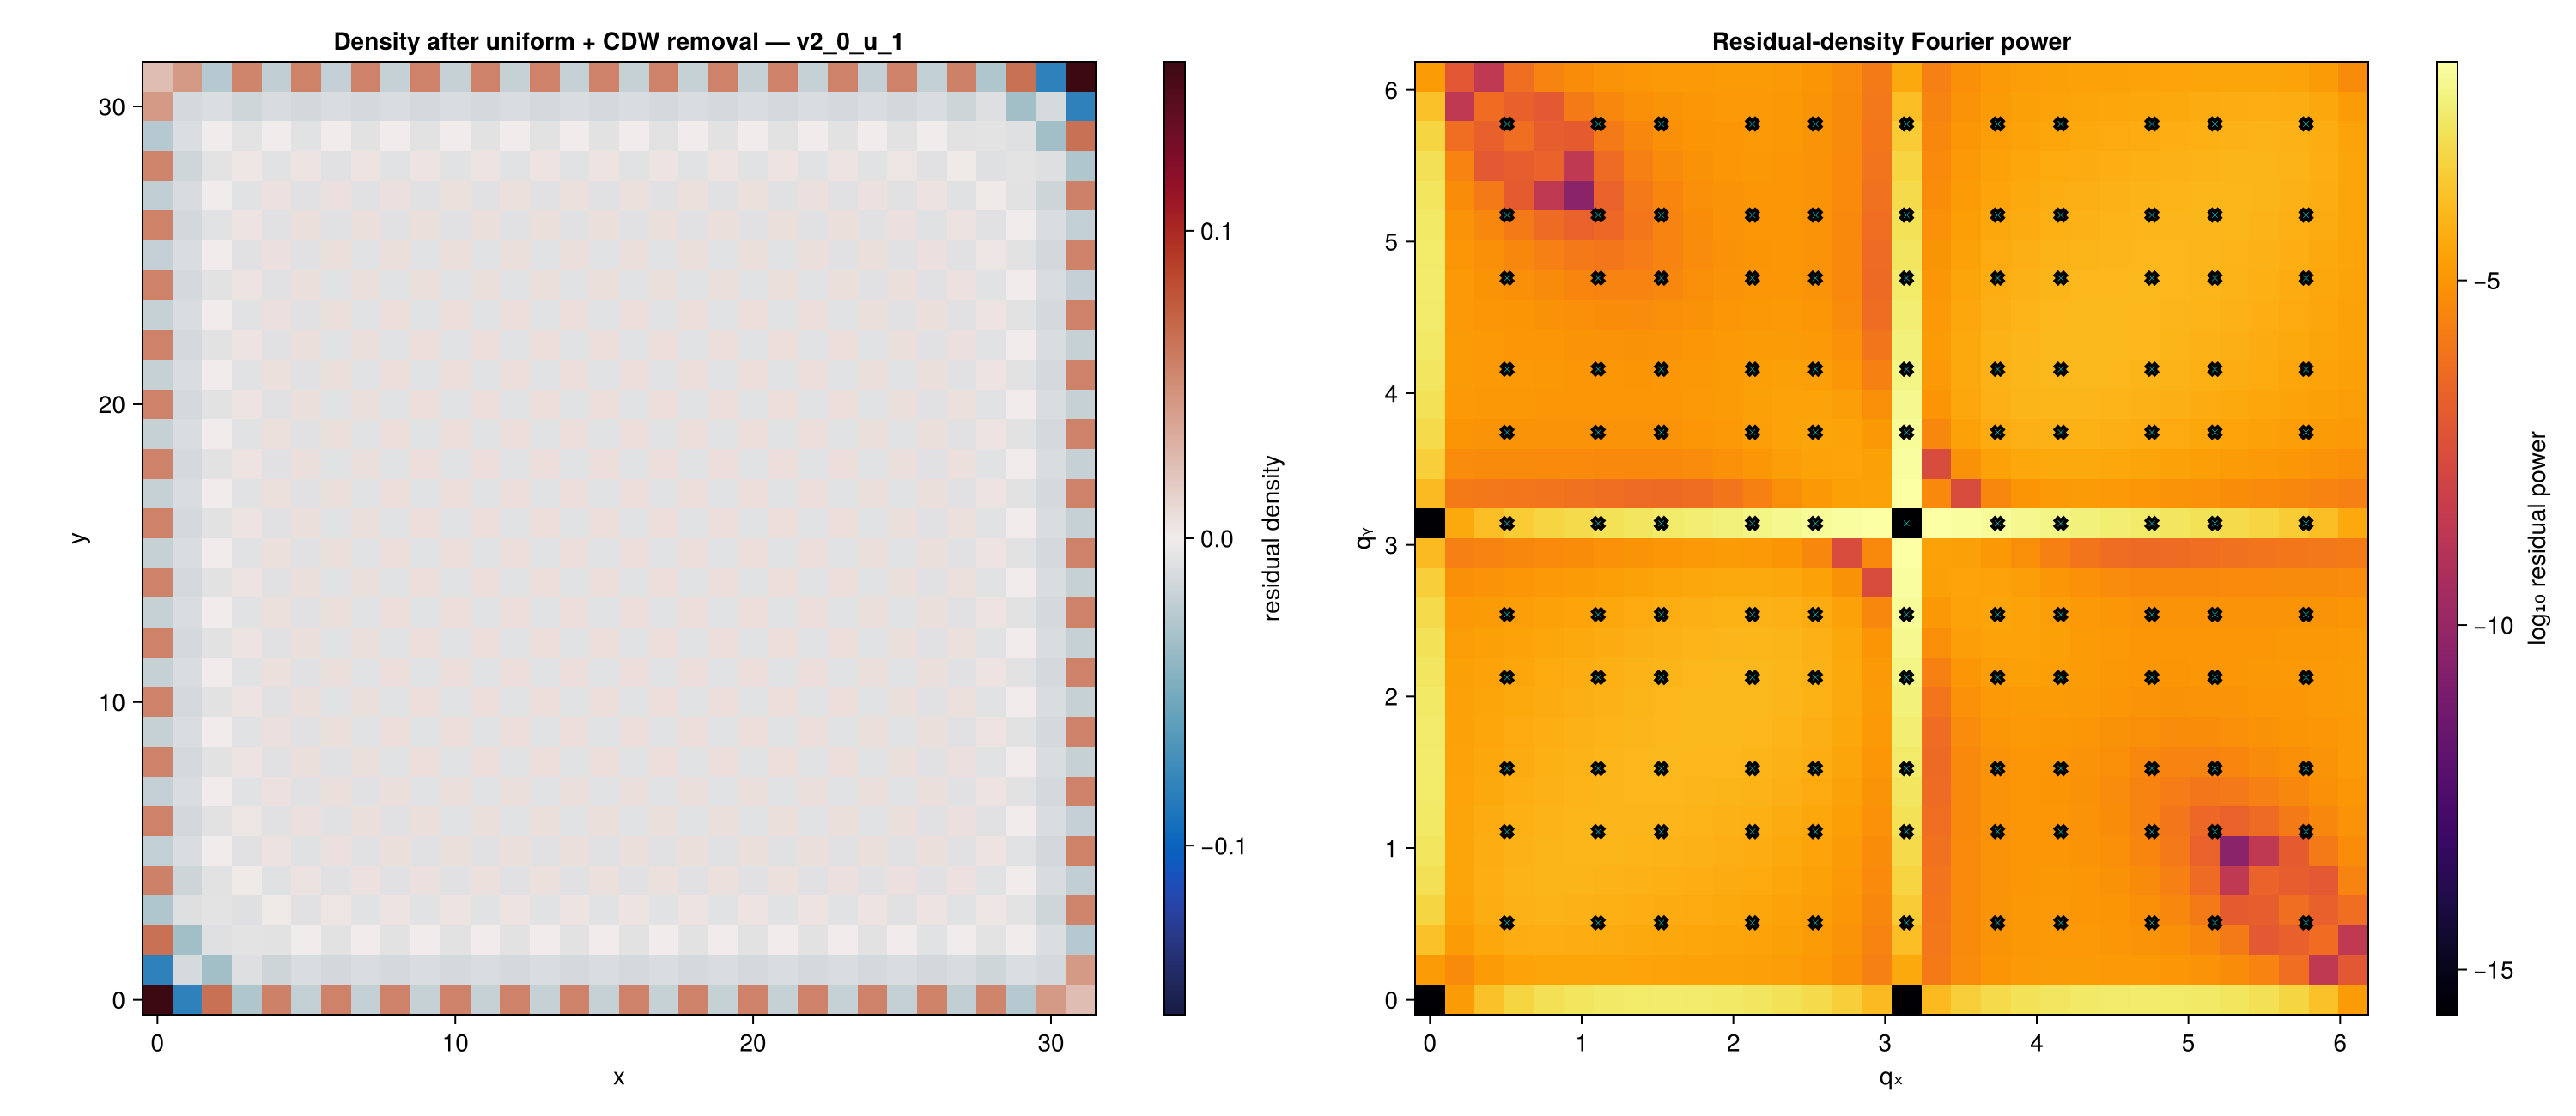

v2_0p5_u_1: mean density = 0.5, fitted CDW amplitude = -0.29808158404674495


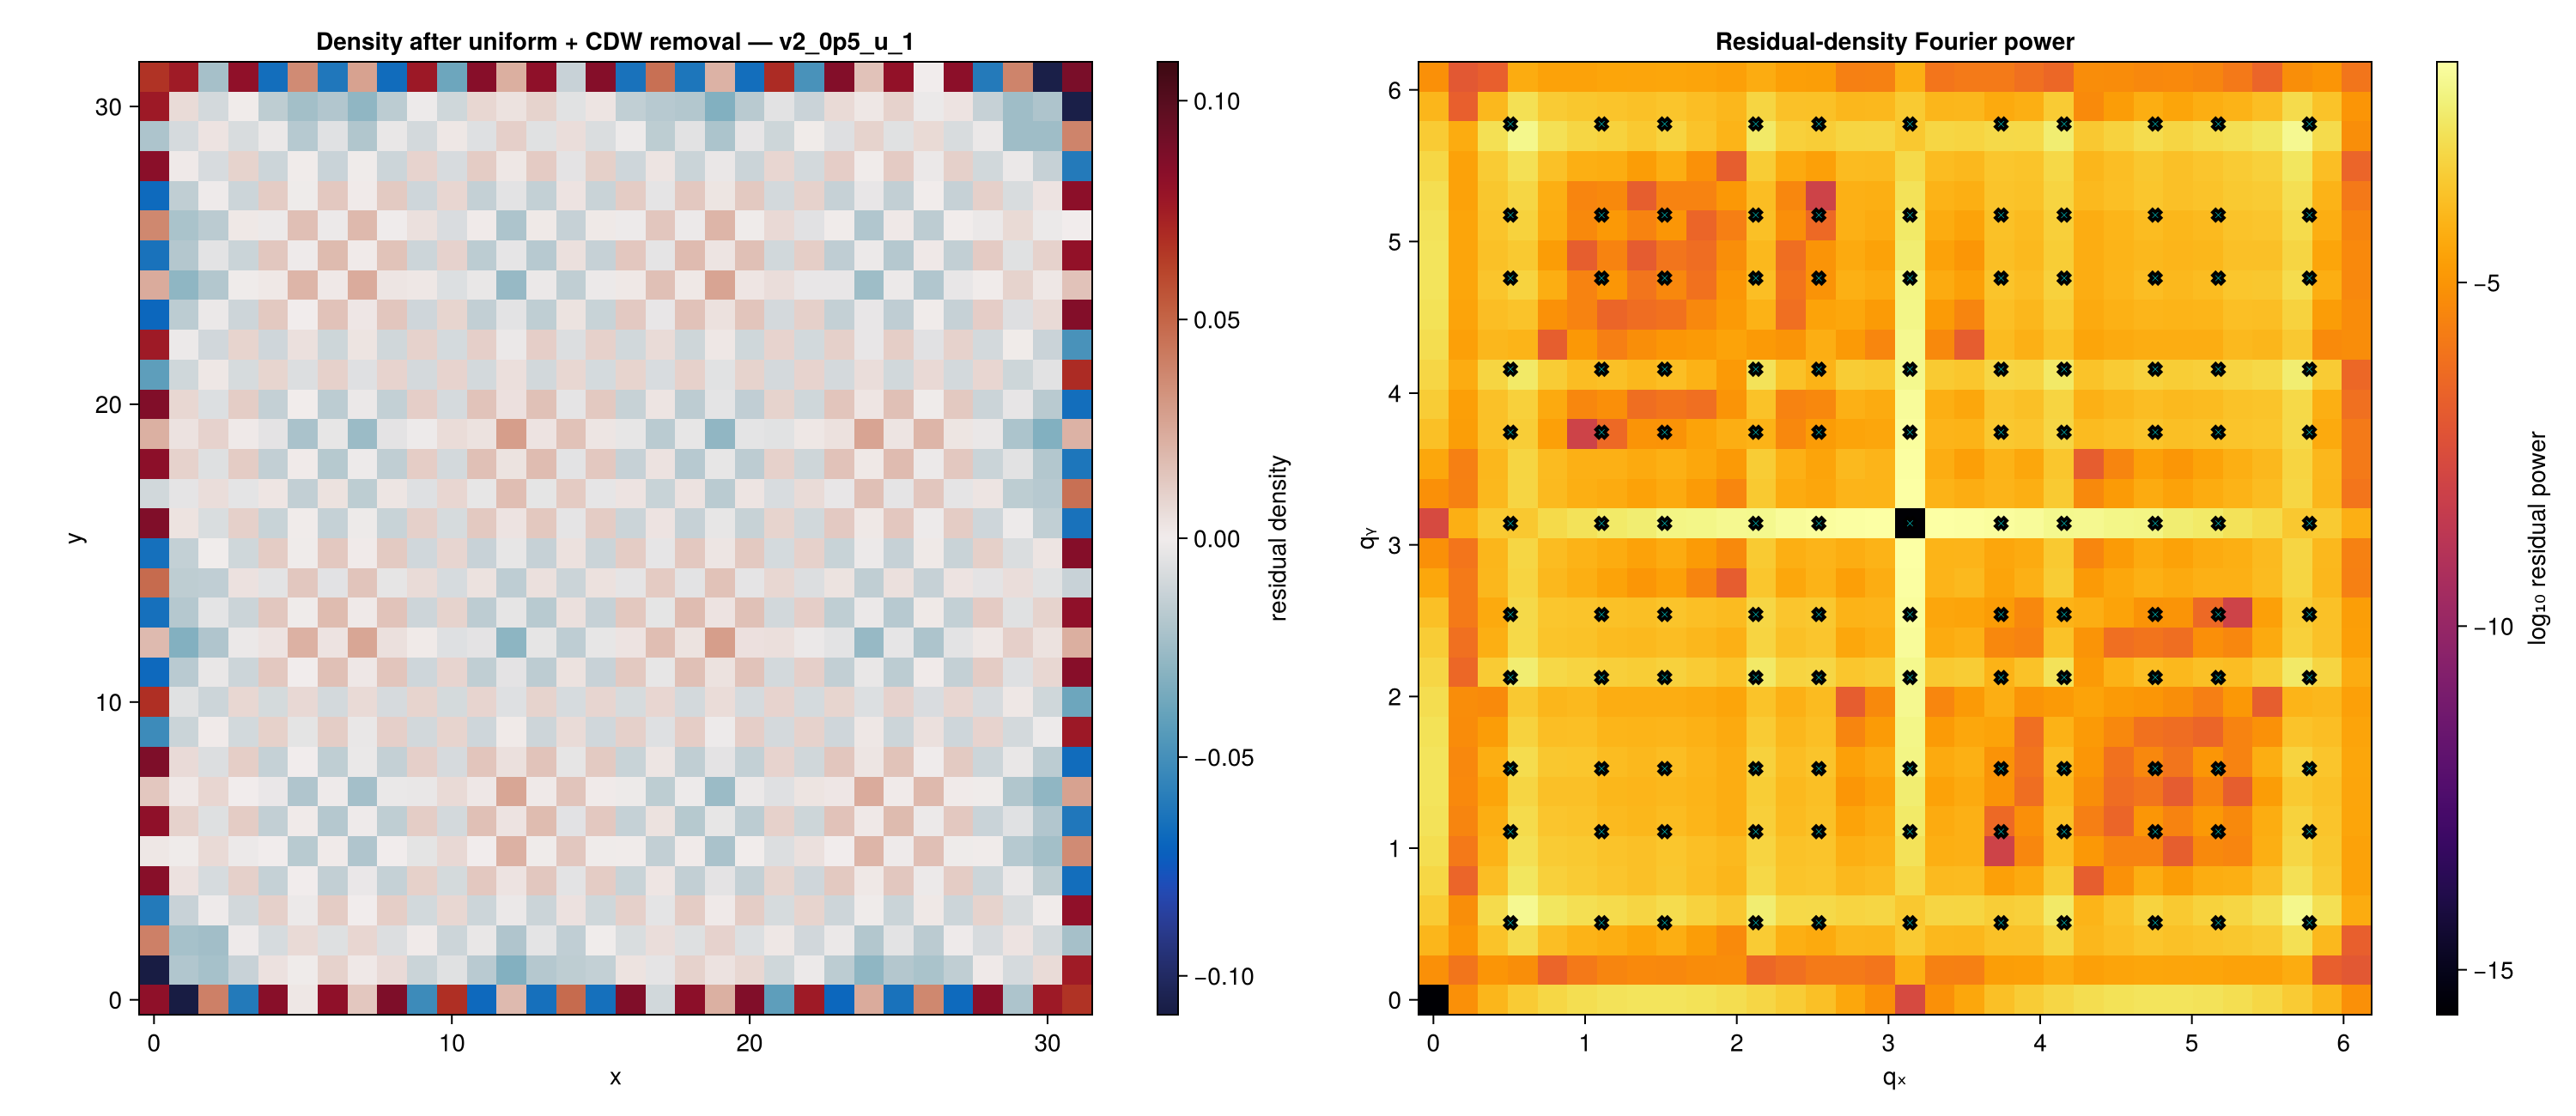

v2_2_u_0p2: mean density = 0.4999999999999999, fitted CDW amplitude = -0.06373305464918579


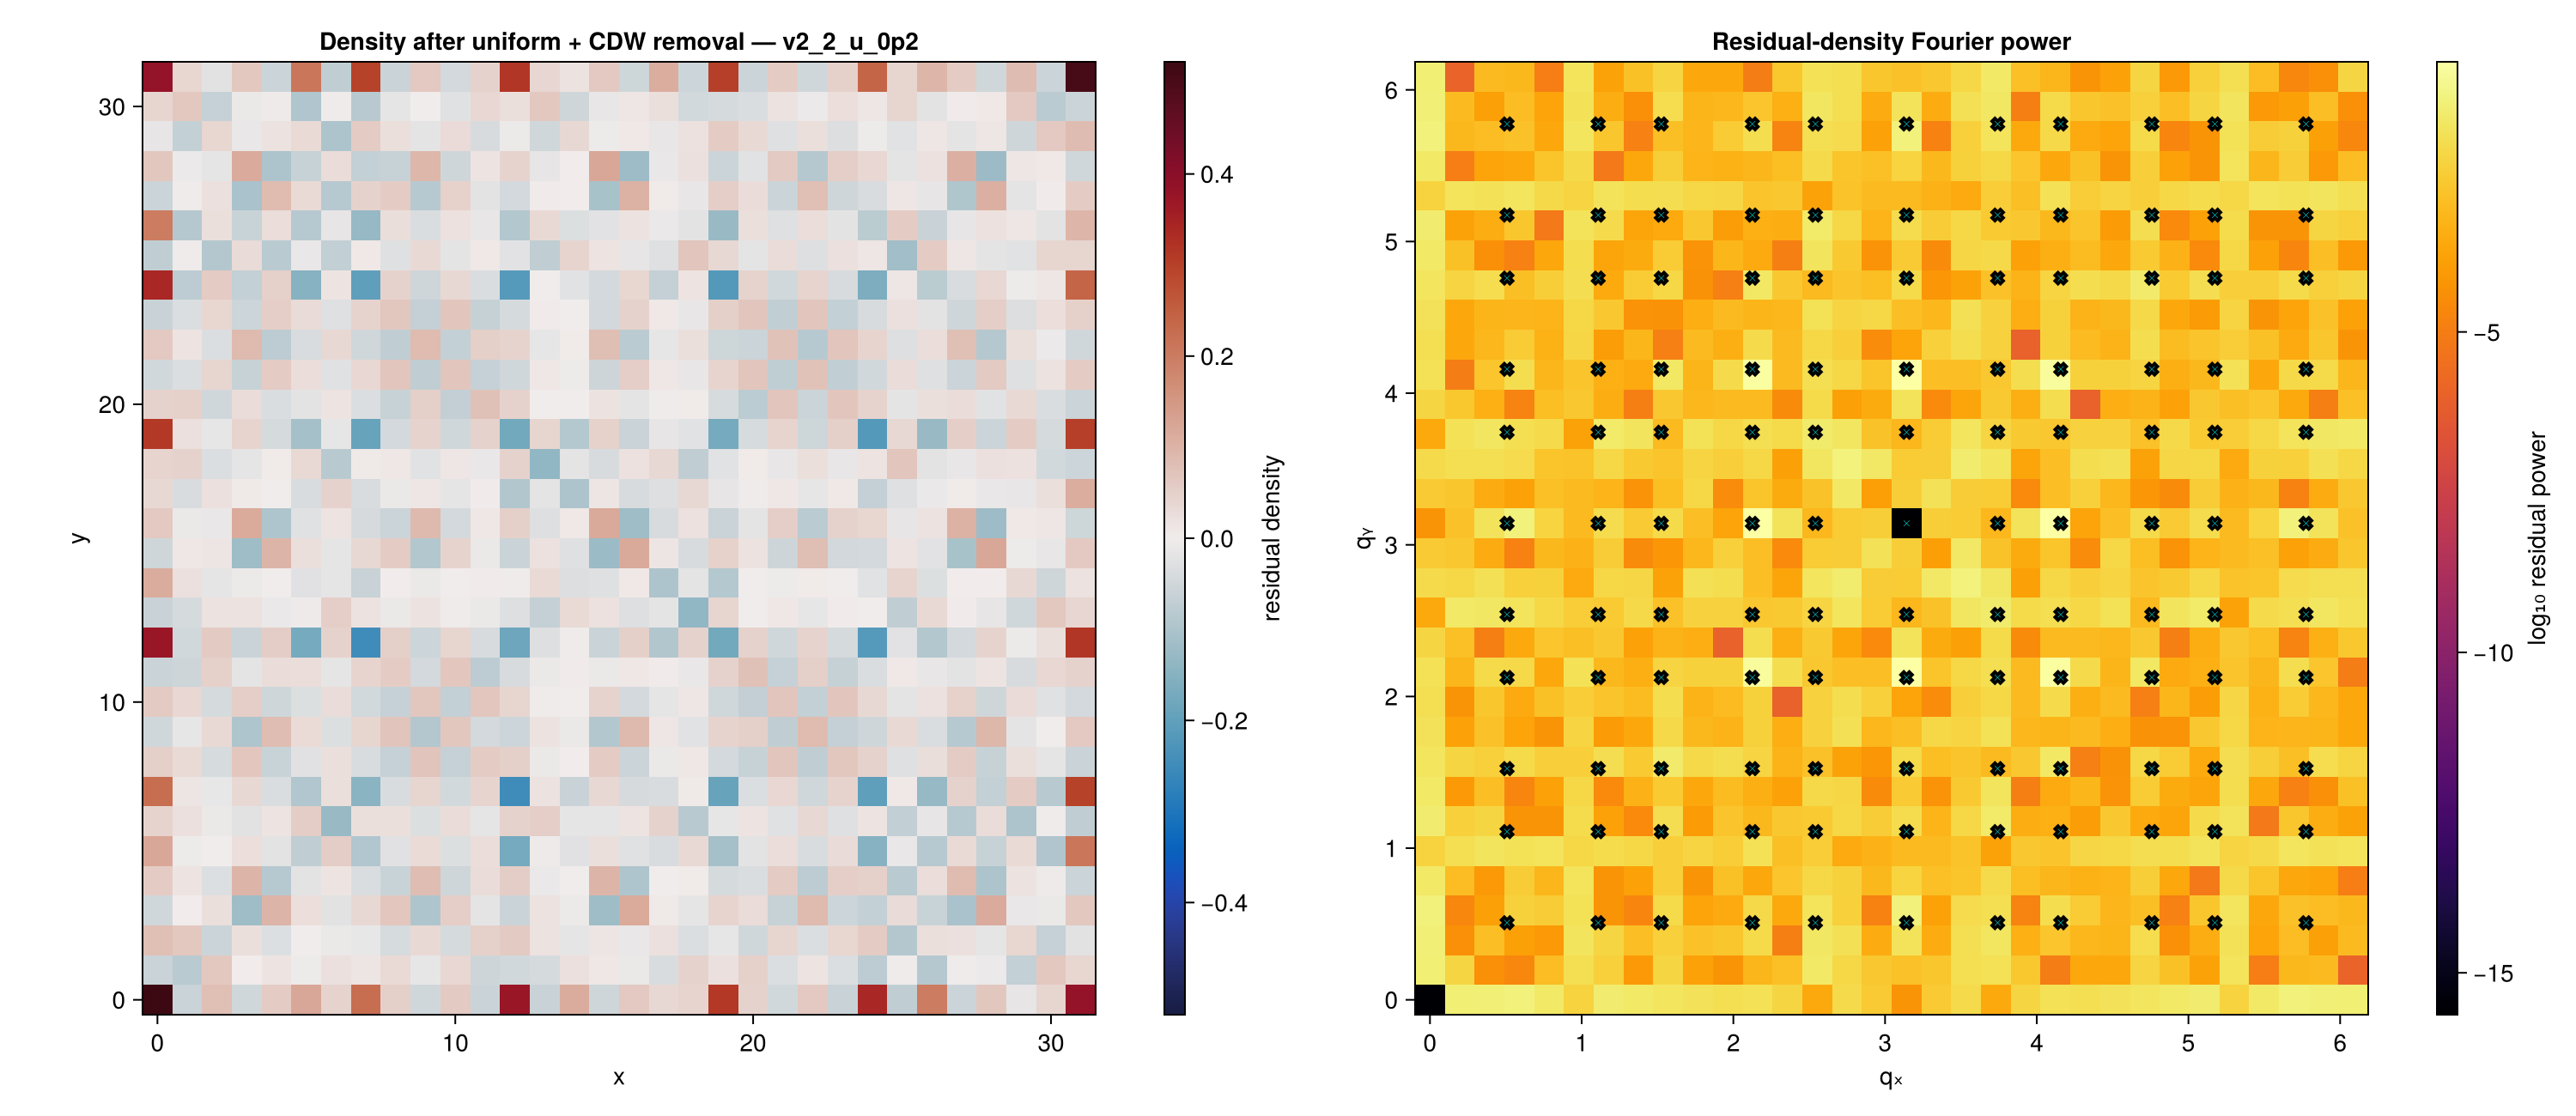

In [8]:
function checkerboard_residual(grid)
    side = size(grid, 1)
    staggered = [iseven(x + y) ? 1.0 : -1.0 for x in 0:(side - 1), y in 0:(side - 1)]
    mean_density = mean(grid)
    cdw_amplitude = mean(staggered .* (grid .- mean_density))
    residual = grid .- mean_density .- cdw_amplitude .* staggered
    return residual, mean_density, cdw_amplitude
end

function fourier_power(field)
    side = size(field, 1)
    q = 2π .* (0:(side - 1)) ./ side
    return q, abs2.(fft(field)) / side^2
end

for entry in cases
    residual, mean_density, cdw_amplitude = checkerboard_residual(entry.grid)
    q, power = fourier_power(residual)
    scale = maximum(abs, residual)
    fig = Figure(size=(1500, 650))
    real_axis = Axis(fig[1, 1], xlabel="x", ylabel="y", aspect=DataAspect(),
        title="Density after uniform + CDW removal — $(entry.label)")
    real_map = heatmap!(real_axis, 0:(size(residual, 1) - 1), 0:(size(residual, 2) - 1), residual; colormap=:balance, colorrange=(-scale, scale))
    Colorbar(fig[1, 2], real_map, label="residual density")
    fft_axis = Axis(fig[1, 3], xlabel="qₓ", ylabel="qᵧ", aspect=DataAspect(), title="Residual-density Fourier power")
    fft_map = heatmap!(fft_axis, q, q, log10.(power .+ eps(Float64)); colormap=:inferno)
    τ = sqrt(2.0) - 5.0 / 6.0
    q_module = unique(sort(mod2pi.(π .+ 2π * τ .* (-5:5))))
    scatter!(fft_axis, repeat(q_module; inner=length(q_module)), repeat(q_module; outer=length(q_module)); marker=:x, markersize=9, strokewidth=2, color=:cyan)
    Colorbar(fig[1, 4], fft_map, label="log₁₀ residual power")
    println("$(entry.label): mean density = $mean_density, fitted CDW amplitude = $cdw_amplitude")
    display(fig)
end

## Direct quasiperiodic response at fixed interaction

This compares `V2=0.5, U=1` against `V2=0, U=1`, which share the same interaction and seed.

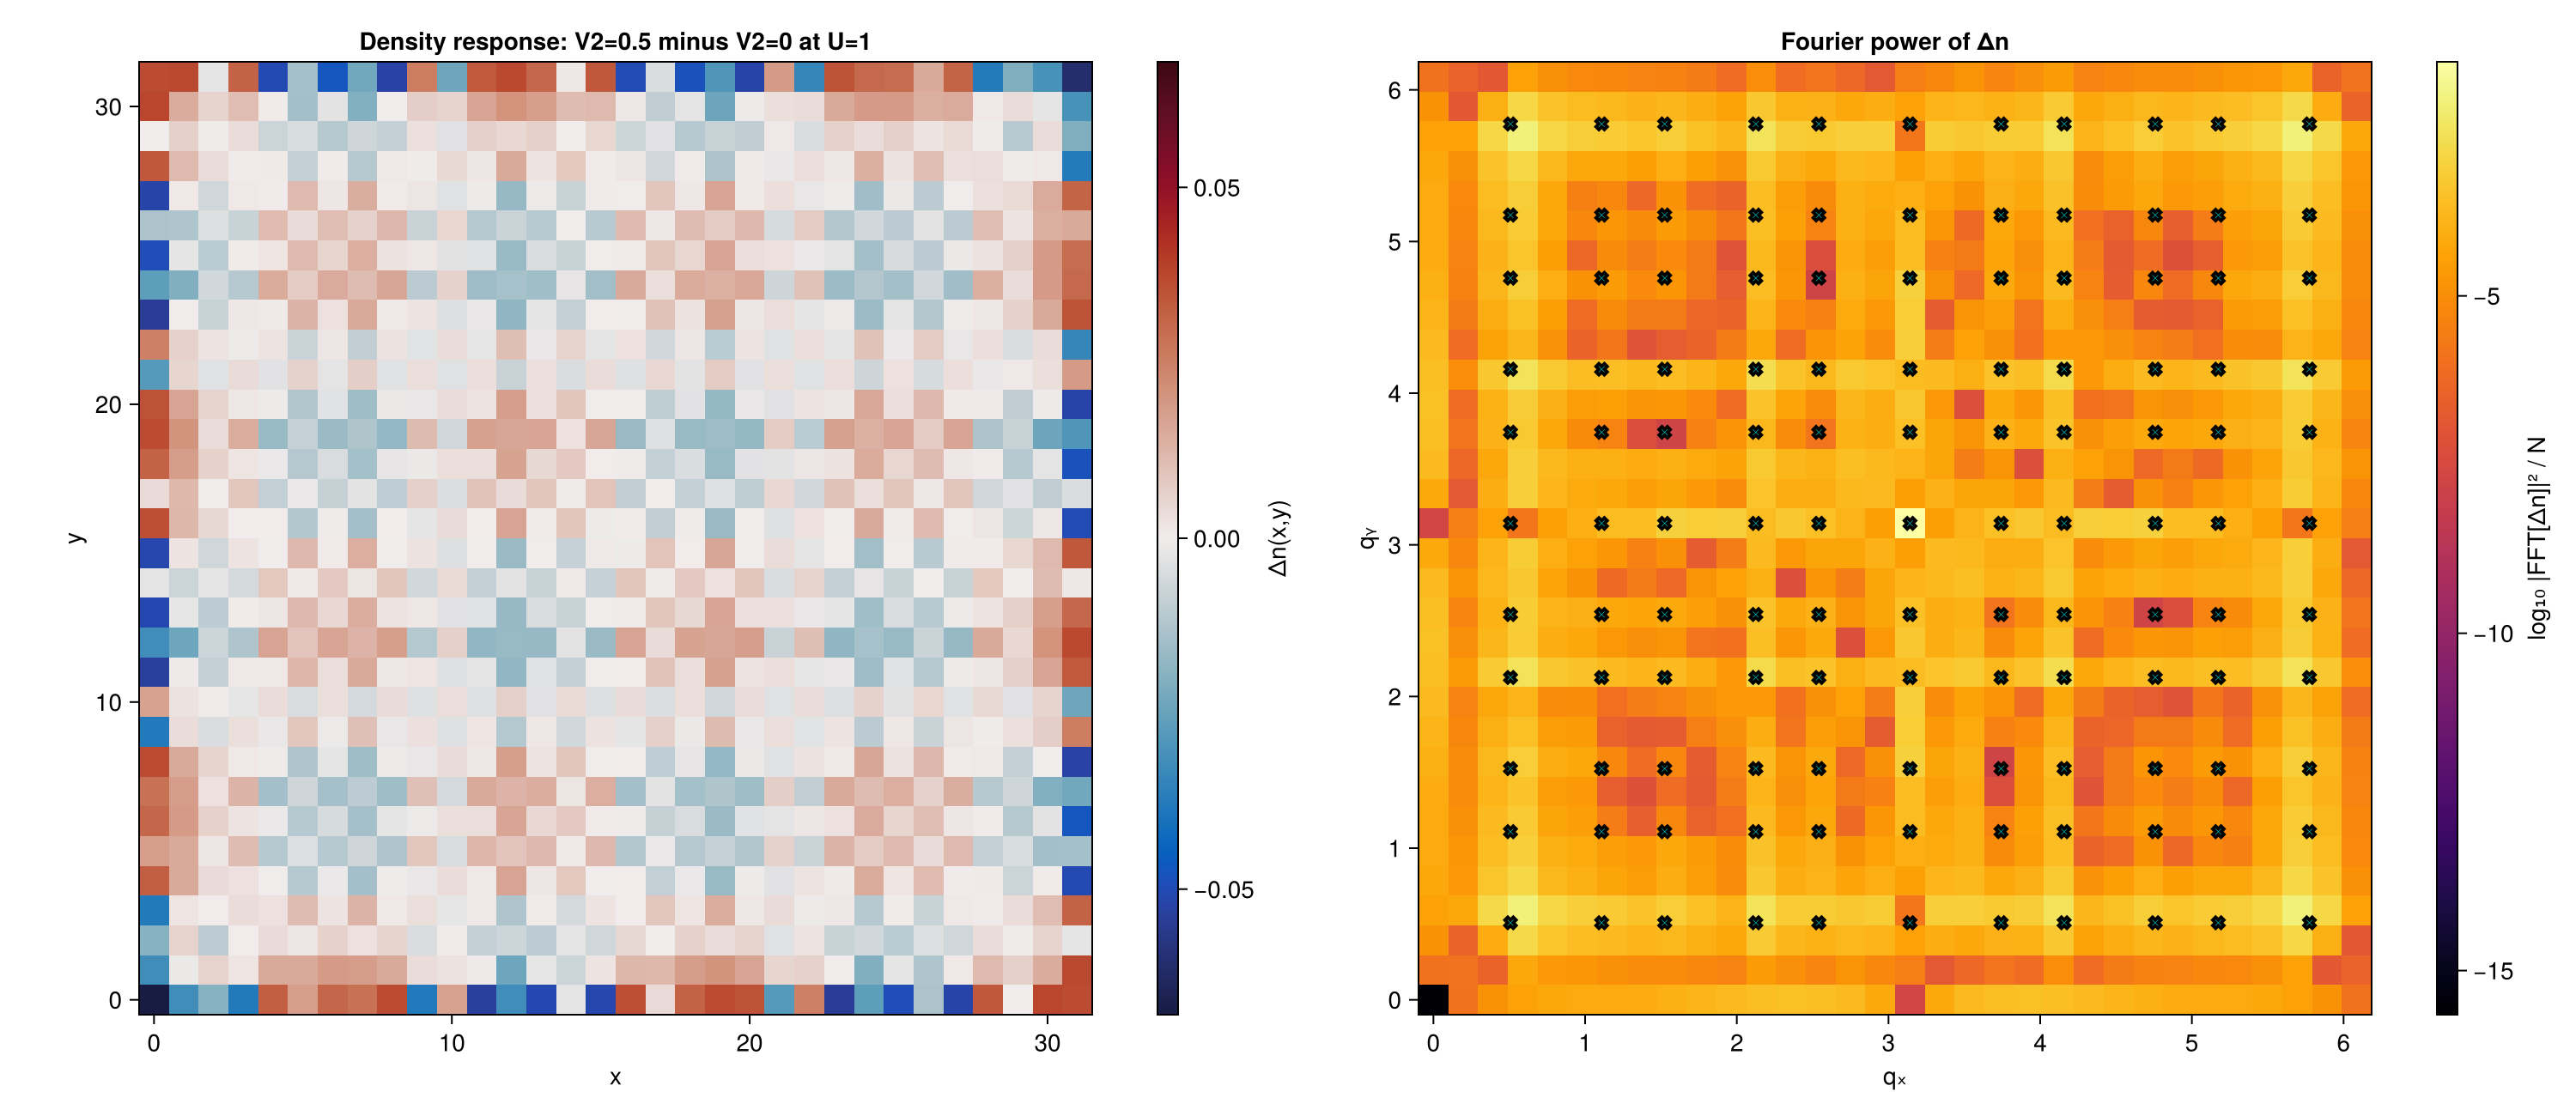

CairoMakie.Screen{IMAGE}


In [9]:
by_label = Dict(entry.label => entry for entry in cases)
if haskey(by_label, "v2_0_u_1") && haskey(by_label, "v2_0p5_u_1")
    response = by_label["v2_0p5_u_1"].grid .- by_label["v2_0_u_1"].grid
    q, response_power = fourier_power(response)
    response_scale = maximum(abs, response)
    fig = Figure(size=(1500, 650))
    response_axis = Axis(fig[1, 1], xlabel="x", ylabel="y", aspect=DataAspect(), title="Density response: V2=0.5 minus V2=0 at U=1")
    response_map = heatmap!(response_axis, 0:(size(response, 1) - 1), 0:(size(response, 2) - 1), response; colormap=:balance, colorrange=(-response_scale, response_scale))
    Colorbar(fig[1, 2], response_map, label="Δn(x,y)")
    fft_axis = Axis(fig[1, 3], xlabel="qₓ", ylabel="qᵧ", aspect=DataAspect(), title="Fourier power of Δn")
    fft_map = heatmap!(fft_axis, q, q, log10.(response_power .+ eps(Float64)); colormap=:inferno)
    τ = sqrt(2.0) - 5.0 / 6.0
    q_module = unique(sort(mod2pi.(π .+ 2π * τ .* (-5:5))))
    scatter!(fft_axis, repeat(q_module; inner=length(q_module)), repeat(q_module; outer=length(q_module)); marker=:x, markersize=9, strokewidth=2, color=:cyan)
    Colorbar(fig[1, 4], fft_map, label="log₁₀ |FFT[Δn]|² / N")
    display(fig)
else
    @warn "The fixed-U comparison needs both v2_0_u_1 and v2_0p5_u_1 result directories."
end